In [29]:
import yfinance as yf
import pandas as pd
import requests

def fetch_data(ticker, start_date=None, end_date=None, interval='1d'):
    """
    Fetches OHCLV stock data and drops missing values
    """
    # Fetch the data
    stock = yf.Ticker(ticker)
    ohlcv_df = stock.history(start=start_date, end=end_date, interval=interval)

    # Remove rows with any missing values
    ohlcv_df_clean = ohlcv_df.dropna()

    # Uncomment below to print the data
    #print(stock.financials)
    #print(stock.balance_sheet)
    #print(stock.cashflow)
    return ohlcv_df_clean

#JPM JNJ PG XOM
#fetch_data(ticker, start_time, end_time)
yf_data = fetch_data("KO", "2025-02-07", "2025-03-06")
3

# The code below requires an API Key which can be generated from the url below. I believe the api allows
# like 1000 requests per month
def fetch_news_articles(ticker,from_date=None, to_date=None, language='en', page_size=100):

    url = 'https://newsapi.org/v2/everything'
    params = {
        'q': ticker,
        'apiKey':"API KEY",
        'language': language,
        'pageSize': page_size,
        'from': from_date,
        'to': to_date,
        'sortBy': 'relevancy'
    }

    response = requests.get(url, params=params)

    data = response.json()

    if data.get('status') == 'ok':
        articles = data.get('articles', [])
        news_df = pd.DataFrame(articles)[['publishedAt', 'title', 'description', 'url', 'content']]
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        return news_df
    else:
        raise Exception(f"Error fetching news: {data.get('message', 'Unknown error')}")

# Only works up to a month back, currently only returns the title and description of articles in a pd
# dataframe. Will probably be updated soon
news_data = fetch_news_articles("KO", "2025-02-07", "2025-03-06")

In [30]:
yf_df = pd.DataFrame(yf_data)
yf_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-02-07 00:00:00-05:00,63.430000,63.919998,63.270000,63.840000,13184700,0.0,0.0
2025-02-10 00:00:00-05:00,64.099998,64.650002,63.660000,64.550003,16154300,0.0,0.0
2025-02-11 00:00:00-05:00,67.500000,67.669998,66.410004,67.599998,30589100,0.0,0.0
2025-02-12 00:00:00-05:00,66.870003,68.820000,66.870003,68.709999,26033800,0.0,0.0
2025-02-13 00:00:00-05:00,69.000000,69.610001,68.760002,69.500000,24393100,0.0,0.0


In [31]:
news_df = pd.DataFrame(news_data)
news_df.head()

,publishedAt,title,description,url,content
0,2025-02-10 15:34:40+00:00,Coca-Cola Company (KO): Among the Best Widow a...,We recently published a list of 10 Best Widow ...,https://finance.yahoo.com/news/coca-cola-compa...,We recently published a list of 10 Best Widow ...
1,2025-02-14 21:35:26+00:00,Breaking Down the Emotional Ending of Melo Mov...,"Netflix’s latest K-drama is a love story, but ...",https://time.com/7225506/melo-movie-ending-exp...,Warning: This article contains spoilers for al...
2,2025-02-20 12:59:11+00:00,What the numbers tell us about Artur Beterbiev...,Artur Beterbiev and Dmitry Bivol meet in a rem...,https://www.espn.com/boxing/story/_/id/4390230...,Artur Beterbiev will make the first defense of...
3,2025-03-02 08:40:35+00:00,Ko finishes well to win in Singapore as Hull f...,World number three Lydia Ko puts in a strong f...,https://www.bbc.com/sport/golf/articles/cwyd3j...,World number three Lydia Ko moved clear of the...
4,2025-03-01 18:15:00+00:00,The 10 Most Anticipated K-Dramas Premiering In...,"K-dramas are all the rage right now, and there...",https://www.slashfilm.com/1801575/most-anticip...,"A deep love of cinema is at the heart of ""Melo..."


In [32]:
import datetime as dt

import pandas as pd
import datetime as dt

# Convert 'publishedAt' in news_df to datetime and remove timezone info
news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt']).dt.tz_localize(None)
news_df['publishedAt'] = news_df['publishedAt'].dt.date

# Convert index of yf_df to 'Date' column and remove timezone info
yf_df['Date'] = yf_df.index
yf_df['Date'] = pd.to_datetime(yf_df['Date']).dt.tz_localize(None).dt.date

# Rename date
yf_df.rename(columns={'Date': 'date'}, inplace=True)

# Merge the two dataframes on the appropriate columns
merged_df = pd.merge(yf_df, news_df, left_on='date', right_on='publishedAt', how='inner')

# Drop 'publishedAt' column after merge
merged_df.drop(columns='publishedAt', inplace=True)

# Display the first few rows of the merged dataframe
merged_df.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,date,title,description,url,content
0,63.43,63.919998,63.27,63.84,13184700,0.0,0.0,2025-02-07,WWE Rumors: Kevin Owens Signed New Contract Pr...,Kevin Owens reportedly signed a new WWE contra...,https://bleacherreport.com/articles/10153999-w...,Andrew Timms/WWE via Getty Images\r\nKevin Owe...
1,63.43,63.919998,63.27,63.84,13184700,0.0,0.0,2025-02-07,Real Madrid Makes Two New ‘Signings’ For Champ...,Spanish soccer giant Real Madrid has made what...,https://www.forbes.com/sites/tomsanderson/2025...,Real Madrid has made what have been dubbed two...
2,63.43,63.919998,63.27,63.84,13184700,0.0,0.0,2025-02-07,"After Oshi no Ko, the Manga's Artist Is Ready ...","After Oshi no Ko, Mengo Yokoyari debuts Ai Bak...",https://screenrant.com/oshi-no-ko-manga-artist...,Manga artist Mengo Yokoyari recently scored a ...
3,63.43,63.919998,63.27,63.84,13184700,0.0,0.0,2025-02-07,Yen Press Licenses Oshi No Ko Spica of the Fir...,Also: Konosuba: Even More Explosions on This W...,https://www.animenewsnetwork.com/news/2025-02-...,Yen Press announced on Friday that it has lice...
4,63.43,63.919998,63.27,63.84,13184700,0.0,0.0,2025-02-07,Former UFC Champion Announces His Retirement I...,Former two-time champion Dominick Cruz formerl...,https://www.forbes.com/sites/brianmazique/2025...,UFC gloves (Photo by Josh Hedges/Zuffa LLC/Zuf...


In [33]:
# Check for missing values

merged_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0
date,0
title,0
description,0


In [34]:
# Renaming columns

merged_df.drop(columns=['url'], inplace=True)
merged_df = merged_df[['date', 'Open', 'High', 'Low', 'Close', 'Volume', 'title', 'description', 'content']]
merged_df.rename(columns={
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'volume'
}, inplace=True)

In [35]:
merged_df.head()

,date,open,high,low,close,volume,title,description,content
0,2025-02-07,63.43,63.919998,63.27,63.84,13184700,WWE Rumors: Kevin Owens Signed New Contract Pr...,Kevin Owens reportedly signed a new WWE contra...,Andrew Timms/WWE via Getty Images\r\nKevin Owe...
1,2025-02-07,63.43,63.919998,63.27,63.84,13184700,Real Madrid Makes Two New ‘Signings’ For Champ...,Spanish soccer giant Real Madrid has made what...,Real Madrid has made what have been dubbed two...
2,2025-02-07,63.43,63.919998,63.27,63.84,13184700,"After Oshi no Ko, the Manga's Artist Is Ready ...","After Oshi no Ko, Mengo Yokoyari debuts Ai Bak...",Manga artist Mengo Yokoyari recently scored a ...
3,2025-02-07,63.43,63.919998,63.27,63.84,13184700,Yen Press Licenses Oshi No Ko Spica of the Fir...,Also: Konosuba: Even More Explosions on This W...,Yen Press announced on Friday that it has lice...
4,2025-02-07,63.43,63.919998,63.27,63.84,13184700,Former UFC Champion Announces His Retirement I...,Former two-time champion Dominick Cruz formerl...,UFC gloves (Photo by Josh Hedges/Zuffa LLC/Zuf...


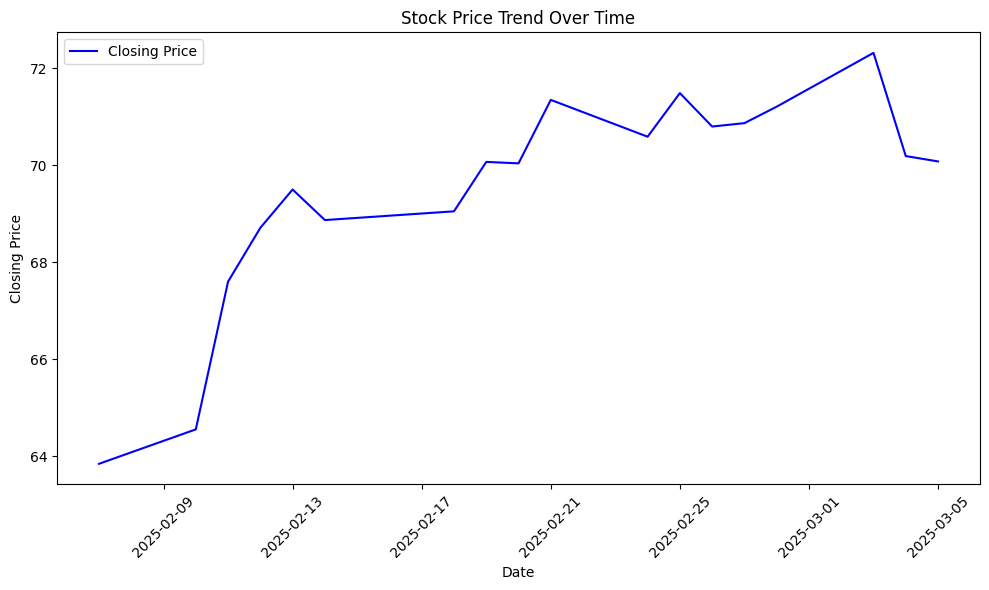

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stock Price Trend (Close Price over Time)
plt.figure(figsize=(10, 6))
plt.plot(merged_df['date'], merged_df['close'], label='Closing Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Stock Price Trend Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    sentiment = analyzer.polarity_scores(text)
    return sentiment['compound']

merged_df['sentiment'] = merged_df['content'].apply(get_sentiment)

merged_df.head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,date,open,high,low,close,volume,title,description,content,sentiment
0,2025-02-07,63.43,63.919998,63.27,63.84,13184700,WWE Rumors: Kevin Owens Signed New Contract Pr...,Kevin Owens reportedly signed a new WWE contra...,Andrew Timms/WWE via Getty Images\r\nKevin Owe...,0.4404
1,2025-02-07,63.43,63.919998,63.27,63.84,13184700,Real Madrid Makes Two New ‘Signings’ For Champ...,Spanish soccer giant Real Madrid has made what...,Real Madrid has made what have been dubbed two...,0.5267
2,2025-02-07,63.43,63.919998,63.27,63.84,13184700,"After Oshi no Ko, the Manga's Artist Is Ready ...","After Oshi no Ko, Mengo Yokoyari debuts Ai Bak...",Manga artist Mengo Yokoyari recently scored a ...,-0.3612
3,2025-02-07,63.43,63.919998,63.27,63.84,13184700,Yen Press Licenses Oshi No Ko Spica of the Fir...,Also: Konosuba: Even More Explosions on This W...,Yen Press announced on Friday that it has lice...,-0.1531
4,2025-02-07,63.43,63.919998,63.27,63.84,13184700,Former UFC Champion Announces His Retirement I...,Former two-time champion Dominick Cruz formerl...,UFC gloves (Photo by Josh Hedges/Zuffa LLC/Zuf...,0.3506


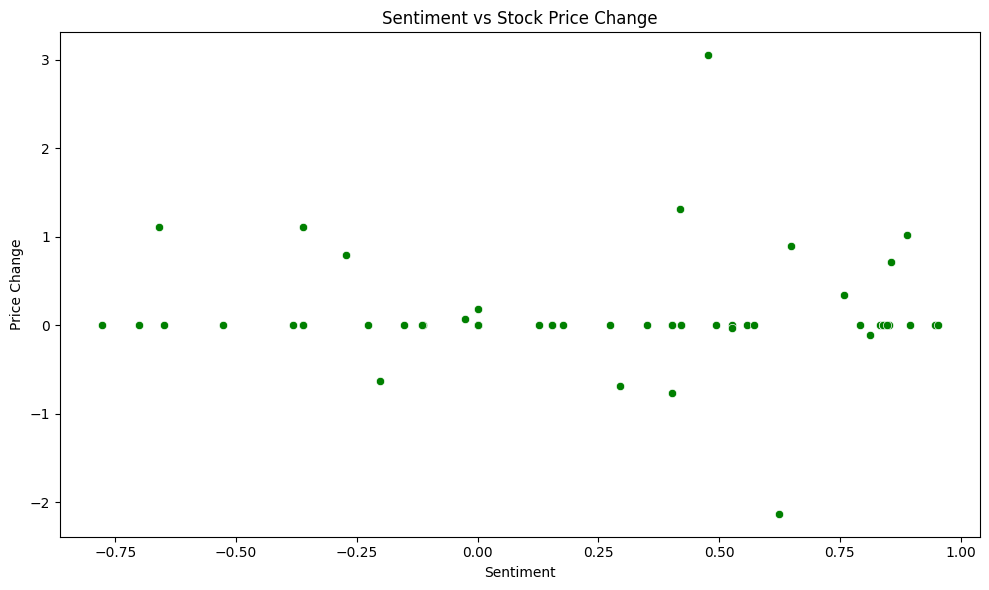

In [38]:
merged_df['price_change'] = merged_df['close'].diff()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_df['sentiment'], y=merged_df['price_change'], color='green')
plt.xlabel('Sentiment')
plt.ylabel('Price Change')
plt.title('Sentiment vs Stock Price Change')
plt.tight_layout()
plt.show()